In [11]:
!pip install scikit-learn pandas matplotlib seaborn

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, accuracy_score, f1_score,
                             roc_curve, auc)

import warnings
warnings.filterwarnings('ignore')

In [13]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

df = pd.read_csv(url, header=None, names=columns, na_values=' ?', skipinitialspace=True)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [14]:
# Drop rows with missing values
df = df.dropna()

# Strip whitespace from string columns
df = df.apply(lambda x: x.str.strip() if x.dtype == 'object' else x)

# Encode outcome variable as 0/1
df['income'] = (df['income'] == '>50K').astype(int)

print("Class balance:")
print(df['income'].value_counts())
print(f"\nPercentage earning >50K: {df['income'].mean()*100:.1f}%")

Class balance:
income
0    24720
1     7841
Name: count, dtype: int64

Percentage earning >50K: 24.1%


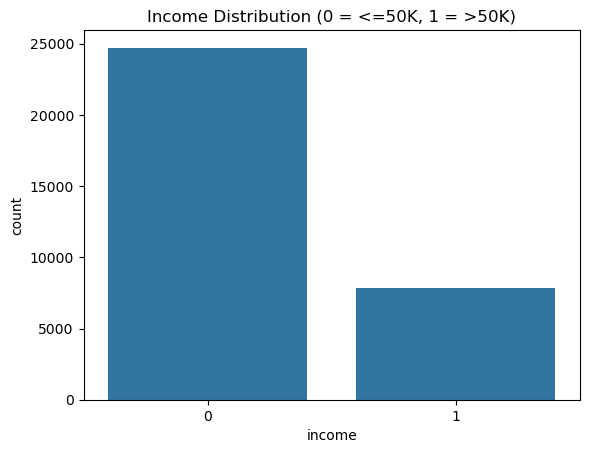

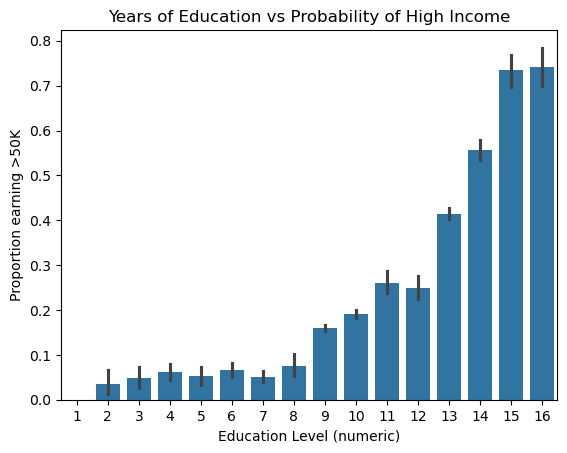

In [15]:
# Plot income distribution
sns.countplot(x='income', data=df)
plt.title('Income Distribution (0 = <=50K, 1 = >50K)')
plt.show()

# Education vs income
sns.barplot(x='education_num', y='income', data=df)
plt.title('Years of Education vs Probability of High Income')
plt.xlabel('Education Level (numeric)')
plt.ylabel('Proportion earning >50K')
plt.show()

In [16]:
# Select features
features = ['age', 'education_num', 'hours_per_week', 'capital_gain',
            'capital_loss', 'sex', 'race', 'workclass', 'marital_status', 'occupation']

df_model = df[features + ['income']].copy()

# Give each categorical column its OWN LabelEncoder
cat_cols = ['sex', 'race', 'workclass', 'marital_status', 'occupation']
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    encoders[col] = le  # saved in case you need to reverse the encoding later

# Split into features (X) and outcome (y)
X = df_model.drop('income', axis=1)
y = df_model['income']

# Stratified 80/20 train-test split
# stratify=y ensures the class balance is equal in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")
print(f"\nClass balance in training set:\n{y_train.value_counts()}")
print(f"\nClass balance in test set:\n{y_test.value_counts()}")

Training set: (26048, 10), Test set: (6513, 10)

Class balance in training set:
income
0    19775
1     6273
Name: count, dtype: int64

Class balance in test set:
income
0    4945
1    1568
Name: count, dtype: int64


In [17]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print(f"AUC-ROC: {roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]):.3f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4945
           1       0.73      0.45      0.56      1568

    accuracy                           0.83      6513
   macro avg       0.79      0.70      0.72      6513
weighted avg       0.82      0.83      0.81      6513

AUC-ROC: 0.859


In [18]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print(f"AUC-ROC: {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.3f}")

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.89      0.92      0.90      4945
           1       0.72      0.63      0.67      1568

    accuracy                           0.85      6513
   macro avg       0.80      0.78      0.79      6513
weighted avg       0.85      0.85      0.85      6513

AUC-ROC: 0.896


,Accuracy,F1 (high earners),AUC-ROC
Model,,,
Logistic Regression,0.827,0.557,0.859
Random Forest,0.852,0.673,0.896


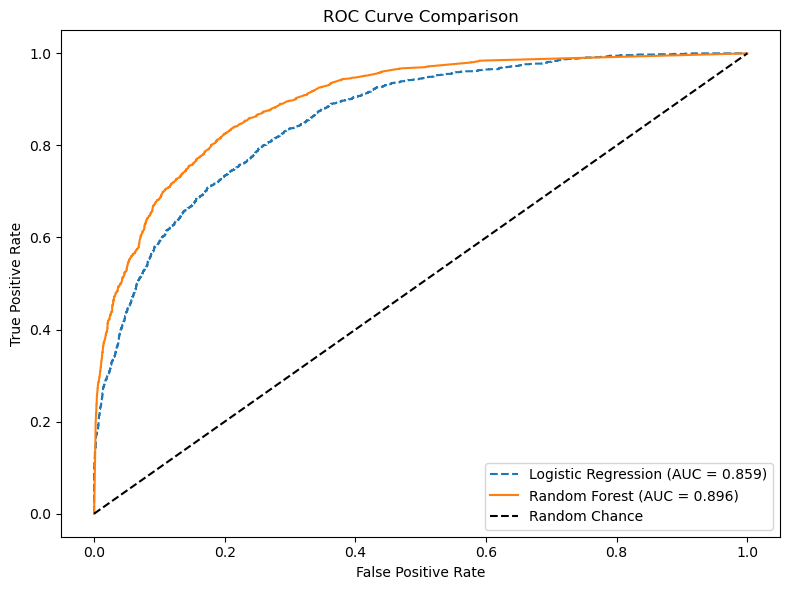

In [21]:
# ── Comparison Table ──────────────────────────────────────────────────────────
results = {
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        round(accuracy_score(y_test, y_pred_lr), 3),
        round(accuracy_score(y_test, y_pred_rf), 3)
    ],
    'F1 (high earners)': [
        round(f1_score(y_test, y_pred_lr), 3),
        round(f1_score(y_test, y_pred_rf), 3)
    ],
    'AUC-ROC': [
        round(roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]), 3),
        round(roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]), 3)
    ]
}

results_df = pd.DataFrame(results).set_index('Model')
display(results_df)  # renders as a proper formatted table in Jupyter

# ── ROC Curve Plot ────────────────────────────────────────────────────────────
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr.predict_proba(X_test)[:,1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf.predict_proba(X_test)[:,1])

auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})', linestyle='--')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()

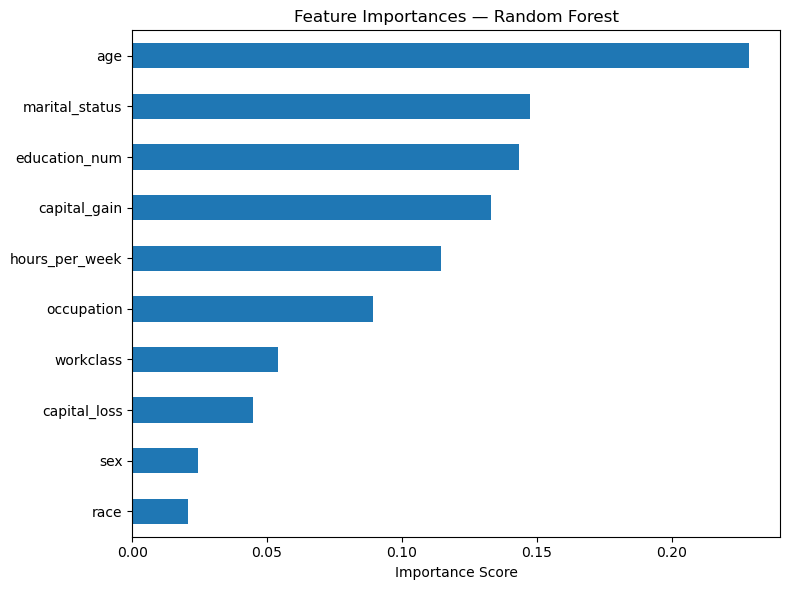

In [20]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title('Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()